In [1]:
# ============================================================
# HÜCRE 1: Kütüphane Kurulumu
# ============================================================

!pip install -q zemberek-python        # Türkçe NLP (stemming)
!pip install -q shap                   # Feature importance
!pip install -q wordcloud              # Görselleştirme
!pip install -q matplotlib seaborn     # Grafik
!pip install -q scikit-learn pandas numpy  # ML & veri

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.4/112.4 kB 10.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 MB 12.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
omegaconf 2.3.0 requires antlr4-python3-runtime==4.9.*, but you have antlr4-python3-runtime 4.8 which is incompatible.


In [2]:
# ============================================================
# HÜCRE 2: Import'lar
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import seaborn as sns
from wordcloud import WordCloud

# NLP
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_absolute_error, accuracy_score)
# Explainability
import shap

# Kaydetme
import joblib
import warnings
warnings.filterwarnings("ignore")

print("✅ Tüm kütüphaneler yüklendi.")

✅ Tüm kütüphaneler yüklendi.


In [3]:
# ============================================================
# HÜCRE 3: Veri Yükleme
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

DOSYA_YOLU = '/content/drive/MyDrive/turkish_ecommerce_reviews/turkish_ecommerce_reviews.csv'

df = pd.read_csv(DOSYA_YOLU)

# --- İlk Bakış ---
print(f"📐 Boyut     : {df.shape}")
print(f"📋 Kolonlar  : {list(df.columns)}")
print(f"❓ Eksik veri:\n{df.isnull().sum()}")
print("\n🔍 İlk 3 satır:")
df.head(3)

Mounted at /content/drive
📐 Boyut     : (272216, 9)
📋 Kolonlar  : ['Rating (Star)', 'Review', 'review_length', 'exclamation_count', 'question_count', 'upper_ratio', 'Brand', 'Product_Name', 'URL']
❓ Eksik veri:
Rating (Star)          0
Review                 0
review_length          0
exclamation_count      0
question_count         0
upper_ratio            0
Brand                359
Product_Name           0
URL                    0
dtype: int64

🔍 İlk 3 satır:


,Rating (Star),Review,review_length,exclamation_count,question_count,upper_ratio,Brand,Product_Name,URL
0,5,3 yıldır tık demedi. :),23,0,0,0.000000,Logitech,Logitech M175 Kablosuz Nano Mouse 910 002777,https://www.hepsiburada.com/logitech-m175-kabl...
1,5,3 yıldır kullanıyorum müthiş,28,0,0,0.000000,Logitech,Logitech M175 Kablosuz Nano Mouse 910 002777,https://www.hepsiburada.com/logitech-m175-kabl...
2,4,ürün bugün elime geçti çok fazla inceleme fırs...,512,0,0,0.009766,Logitech,Logitech M175 Kablosuz Nano Mouse 910 002777,https://www.hepsiburada.com/logitech-m175-kabl...


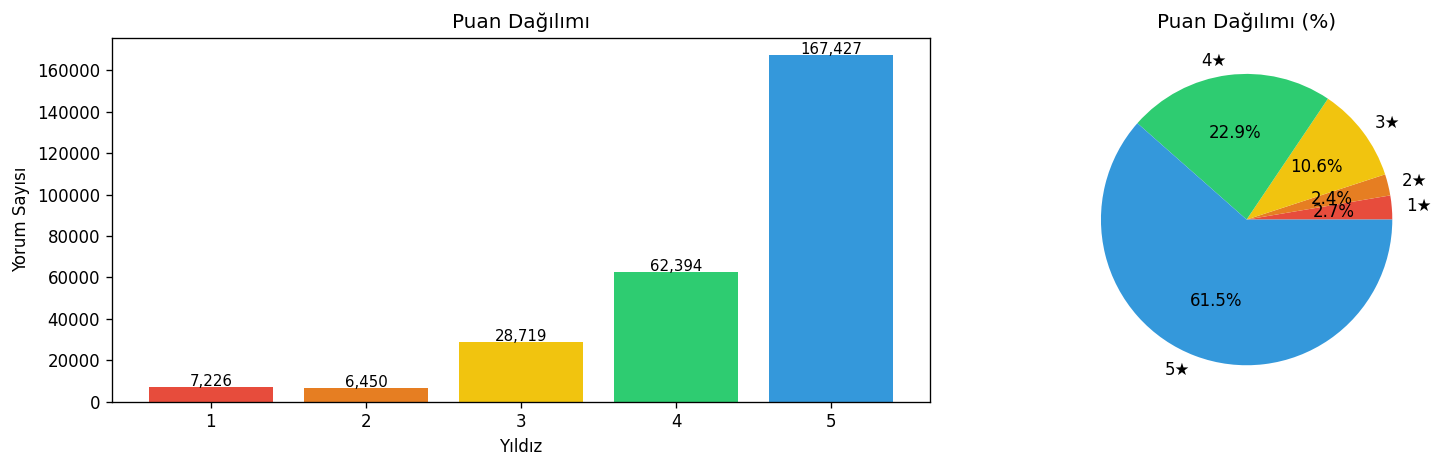

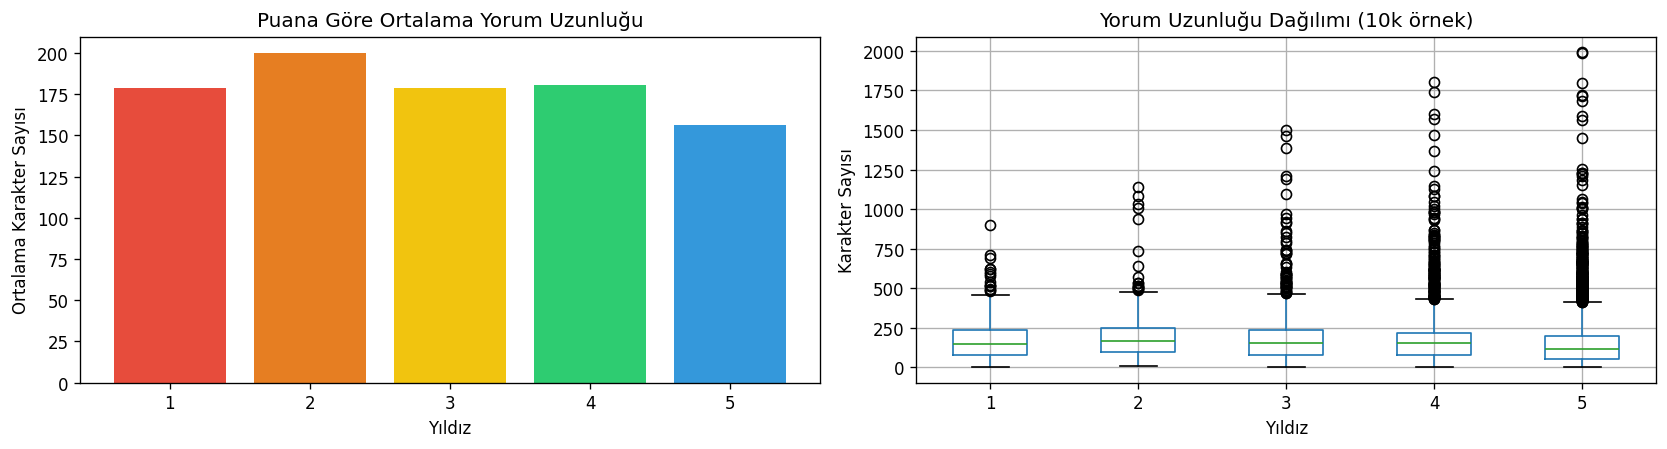

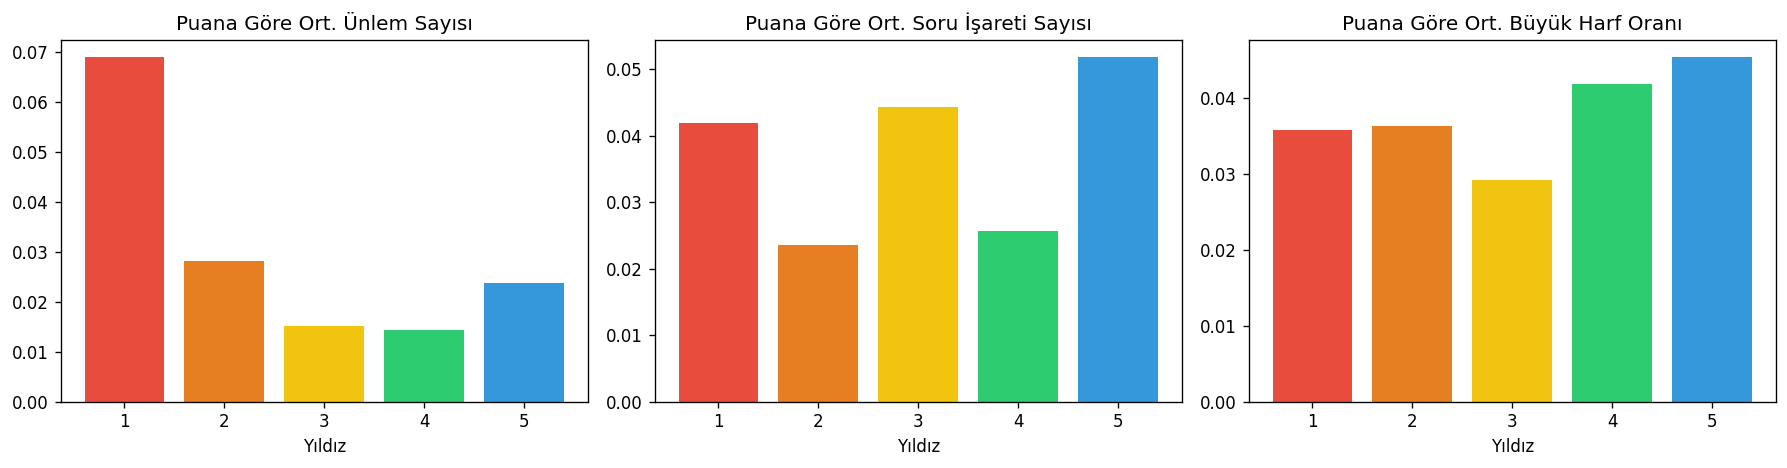

📊 Özet İstatistikler:
           count   mean    std  min   25%    50%    75%     max
rating                                                         
1         7226.0  178.7  153.0  3.0  78.0  145.0  228.0  1994.0
2         6450.0  200.0  166.5  3.0  98.0  166.0  248.0  1995.0
3        28719.0  178.6  156.7  3.0  79.0  151.0  221.0  2012.0
4        62394.0  180.6  161.8  3.0  77.0  157.0  221.0  2000.0
5       167427.0  156.3  161.9  3.0  54.0  117.0  199.0  2057.0


In [4]:
# ============================================================
# HÜCRE 4: EDA & Görselleştirme
# ============================================================

# --- Kolon isimlerini standartlaştır ---
df.rename(columns={'Rating (Star)': 'rating'}, inplace=True)

# ── 4.1 Puan Dağılımı ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
rating_counts = df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'])
axes[0].set_title('Puan Dağılımı')
axes[0].set_xlabel('Yıldız')
axes[0].set_ylabel('Yorum Sayısı')
for i, v in zip(rating_counts.index, rating_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

# Yüzde pasta
axes[1].pie(rating_counts.values,
            labels=[f'{i}★' for i in rating_counts.index],
            autopct='%1.1f%%',
            colors=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'])
axes[1].set_title('Puan Dağılımı (%)')
plt.tight_layout()
plt.show()

# ── 4.2 Yorum Uzunluğu Analizi ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Puana göre ortalama uzunluk
avg_len = df.groupby('rating')['review_length'].mean()
axes[0].bar(avg_len.index, avg_len.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'])
axes[0].set_title('Puana Göre Ortalama Yorum Uzunluğu')
axes[0].set_xlabel('Yıldız')
axes[0].set_ylabel('Ortalama Karakter Sayısı')

# Dağılım (boxplot)
df_sample = df.sample(10000, random_state=42)  # 272k için sample al
df_sample.boxplot(column='review_length', by='rating', ax=axes[1])
axes[1].set_title('Yorum Uzunluğu Dağılımı (10k örnek)')
axes[1].set_xlabel('Yıldız')
axes[1].set_ylabel('Karakter Sayısı')
plt.suptitle('')
plt.tight_layout()
plt.show()

# ── 4.3 Metadata Özellikleri Analizi ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(axes,
    ['exclamation_count', 'question_count', 'upper_ratio'],
    ['Ünlem Sayısı', 'Soru İşareti Sayısı', 'Büyük Harf Oranı']):
    avg = df.groupby('rating')[col].mean()
    ax.bar(avg.index, avg.values,
           color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'])
    ax.set_title(f'Puana Göre Ort. {title}')
    ax.set_xlabel('Yıldız')

plt.tight_layout()
plt.show()

# ── 4.4 Özet İstatistik ────────────────────────────────────
print("📊 Özet İstatistikler:")
print(df.groupby('rating')['review_length'].describe().round(1))

In [ ]:
# ============================================================
# HÜCRE 5.A: Kelime Frekans İşlemleri (Stopwords Listesi İçin)
# ============================================================
from collections import Counter
import re, string

# ── Metin Temizle & Counter Oluştur ────────────────
def build_word_counter(df, text_col='Review'):
    """
    DataFrame'deki metin sütunundan kelime frekans sayacı oluşturur.
    Returns: Counter objesi
    """
    def _clean(text):
        if not isinstance(text, str):
            return ""
        text = text.lower()
        text = re.sub(r'http\S+', '', text)
        text = re.sub(r'\d+', '', text)
        text = text.translate(str.maketrans('', '', string.punctuation))
        return text

    print(f"⏳ '{text_col}' sütunu işleniyor...")
    all_text = ' '.join(df[text_col].apply(_clean))
    words = [w for w in all_text.split() if len(w) > 1]
    word_counter = Counter(words)
    print(f"✅ Unique kelime: {len(word_counter):,} | Toplam token: {sum(word_counter.values()):,}")
    return word_counter


# ── Counter'ı TXT'ye Kaydet ────────────────────────
def save_word_frequencies(word_counter, save_path, min_freq=1):
    """
    Kelime frekanslarını TXT dosyasına kaydeder.
    min_freq: sadece bu frekans ve üzerindeki kelimeleri yazar
    """
    filtered = [(w, f) for w, f in word_counter.most_common() if f >= min_freq]

    with open(save_path, 'w', encoding='utf-8') as file:
        file.write(f"Toplam unique kelime (min_freq={min_freq}): {len(filtered):,}\n")
        file.write(f"Toplam token sayısı: {sum(word_counter.values()):,}\n")
        file.write("=" * 40 + "\n")
        file.write(f"{'Kelime':<25} {'Frekans':>10}\n")
        file.write("=" * 40 + "\n")
        for word, freq in filtered:
            file.write(f"{word:<25} {freq:>10,}\n")

    print(f"💾 Kaydedildi → {save_path}")
    print(f"📋 Yazılan kelime sayısı: {len(filtered):,}")


# ── Frekansa Göre Kelime Listesi Getir ─────────────
def get_words_by_freq(word_counter, min_freq=1, max_freq=None, top_n=None):
    """
    Frekans aralığına göre kelime listesi döndürür.
    min_freq : en az bu kadar geçmeli
    max_freq : en fazla bu kadar geçmeli (None = sınırsız)
    top_n    : sadece ilk N kelimeyi döndür (None = hepsi)
    Returns  : [(kelime, frekans), ...] listesi
    """
    result = [
        (w, f) for w, f in word_counter.most_common()
        if f >= min_freq and (max_freq is None or f <= max_freq)
    ]
    if top_n:
        result = result[:top_n]
    return result


# ── KULLANIM ─────────────────────────────────────────────────
DRIVE_PATH = '/content/drive/MyDrive/turkish_ecommerce_reviews/'

# Counter oluştur (bir kez çalıştır, sonra tekrar kullan)
word_counter = build_word_counter(df, text_col='Review')

# Tüm listeyi kaydet
save_word_frequencies(word_counter,
                      save_path=DRIVE_PATH + 'words_all.txt',
                      min_freq=1)

# 200+ frekans listesini kaydet
save_word_frequencies(word_counter,
                      save_path=DRIVE_PATH + 'words_200plus.txt',
                      min_freq=200)

# Örnek kullanım — sonraki hücrelerde böyle çağırırsın:
# top_words   = get_words_by_freq(word_counter, min_freq=200)
# rare_words  = get_words_by_freq(word_counter, min_freq=1, max_freq=5)
# top_50      = get_words_by_freq(word_counter, top_n=50)

words_200plus = get_words_by_freq(word_counter, min_freq=200)
print(f"\n✅ Frekans 200+ kelime sayısı: {len(words_200plus):,}")

⏳ 'Review' sütunu işleniyor...
✅ Unique kelime: 311,947 | Toplam token: 6,193,475
💾 Kaydedildi → /content/drive/MyDrive/turkish_ecommerce_reviews/words_all.txt
📋 Yazılan kelime sayısı: 311,947
💾 Kaydedildi → /content/drive/MyDrive/turkish_ecommerce_reviews/words_200plus.txt
📋 Yazılan kelime sayısı: 3,040

✅ Frekans 200+ kelime sayısı: 3,040


In [5]:
# ============================================================
# HÜCRE 5B: Stopword Listesini Yükle
# ============================================================

STOPWORDS_PATH = '/content/drive/MyDrive/turkish_ecommerce_reviews/stopwords_final.txt'

def load_stopwords(path):
    with open(path, 'r', encoding='utf-8') as f:
        return set(line.strip() for line in f if line.strip())

STOPWORDS = load_stopwords(STOPWORDS_PATH)

print(f"✅ Stopword yüklendi: {len(STOPWORDS)} kelime")
print(f"🔍 Örnek: {list(STOPWORDS)[:10]}")

✅ Stopword yüklendi: 935 kelime
🔍 Örnek: ['ayrica', 'günler', 'tabii', 'markaya', 'kullanmıyorum', 'verdim', 'şunu şimdi?', 'desem', 'yazıyorum', 'android']


In [6]:
# ============================================================
# HÜCRE 5C: Metin Temizleme
# ============================================================
import re
import string

def full_clean(text, stopwords=STOPWORDS):
    if not isinstance(text, str) or text.strip() == '':
        return ''

    # 1. Küçük harf
    text = text.lower()

    # 2. URL temizle
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Sayı temizle
    text = re.sub(r'\d+', '', text)

    # 4. Noktalama temizle
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 5. Fazla boşluk temizle
    text = re.sub(r'\s+', ' ', text).strip()

    # 6. Stopword çıkar + min 2 karakter filtresi
    tokens = [
        word for word in text.split()
        if word not in stopwords and len(word) > 1
    ]

    return ' '.join(tokens)


# ── Uygula ───────────────────────────────────────────────────
print("⏳ Metinler temizleniyor (~1-2 dk)...")
df['review_clean'] = df['Review'].apply(full_clean)
print("✅ Temizleme tamamlandı.")

# ── Boş kalan yorumları düşür ────────────────────────────────
before = len(df)
df = df[df['review_clean'].str.strip() != ''].reset_index(drop=True)
print(f"🗑️  Düşürülen satır: {before - len(df)}")
print(f"📐 Yeni boyut      : {df.shape}")

# ── Karşılaştırma ────────────────────────────────────────────
print("\n📋 Örnek Karşılaştırma:")
for i in range(3):
    print(f"\n{'─'*60}")
    print(f"[{i}] ORİJİNAL  : {df['Review'].iloc[i]}")
    print(f"[{i}] TEMİZLENMİŞ: {df['review_clean'].iloc[i]}")

# ── Temizleme Sonrası İstatistik ─────────────────────────────
df['clean_length'] = df['review_clean'].apply(lambda x: len(x.split()))

print(f"\n📊 Temizleme Sonrası Token İstatistikleri:")
print(df.groupby('rating')['clean_length'].describe().round(1))

⏳ Metinler temizleniyor (~1-2 dk)...
✅ Temizleme tamamlandı.
🗑️  Düşürülen satır: 113
📐 Yeni boyut      : (272103, 10)

📋 Örnek Karşılaştırma:

────────────────────────────────────────────────────────────
[0] ORİJİNAL  : 3 yıldır tık demedi. :)
[0] TEMİZLENMİŞ: tık demedi

────────────────────────────────────────────────────────────
[1] ORİJİNAL  : 3 yıldır kullanıyorum müthiş
[1] TEMİZLENMİŞ: kullanıyorum müthiş

────────────────────────────────────────────────────────────
[2] ORİJİNAL  : ürün bugün elime geçti çok fazla inceleme fırsatım olmadı ancak gözüme çarpan ilk şey usb bağlantısı için pil kapağının altında çok güzel yer yapmış olmaları, daha önceden o aparatı kaybetmiş biri olarak bu özelliğini çok sevdim. ayrıca 1000dpi olması çok iyi bu tip farelerin çoğu 800dpi oluyor. eğer sizde benim gibi masaüstü bilgisayarınızdan oyuncu faresi ile yüksek dpi ayarına alışmış biriyseniz windows ayarından fareyi en hızlıya getirin ve bu fareyi sipariş verin pişman olmazsınız. teşekkürler l